# TCCT S92B - Paired Relational-Contrast Decoder Training and Freeze

S92B is an outer-decoder development stage using the already revealed S92 labels. It is not blind. The TCCT propagation core, the S87D 27-dimensional feature runtime, canonicalization, undirected freezing, and deduplication are not loaded or changed.

Unlike the failed single-world S87D classifier, this candidate compares two matched alternative worlds for the same query. It searches only unary relational positions 3-17, excludes all cardinality and pair-count positions, and requires perfect leave-one-answer-out validation before export. This is a new paired outer interface; it does not claim that the old single-world decoder has been repaired.

Run **Kernel -> Restart Kernel and Run All Cells**. Expected runtime is under one minute because no graph propagation or Wolfram Classify training is run.


In [313]:
ClearAll["Global`*"];
$HistoryLength=0;
<|"WolframVersion"->$Version,"SystemID"->$SystemID,
"ProcessorCount"->$ProcessorCount|>

<|WolframVersion -> 15.0.0 for Microsoft Windows (64-bit) (May 26, 2026), 
 
>   SystemID -> Windows-x86-64, ProcessorCount -> 10|>

Dataset[{<|Stage -> S92B-PREFLIGHT, Passed -> True, Worlds -> 80, ExpectedPairs -> 40, 
 
>     S92BlindOutcome -> S92_VALID_BLIND_FAILURE_DO_NOT_RETUNE, 
 
>     S92AAuditOutcome -> S92A_VALID_FAILURE_MECHANISM_AUDIT_COMPLETE, 
 
>     CoreLoaded -> False, BaseDecoderChanged -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Passed, Worlds, ExpectedPairs, 
 
>      S92BlindOutcome, S92AAuditOutcome, CoreLoaded, BaseDecoderChanged}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
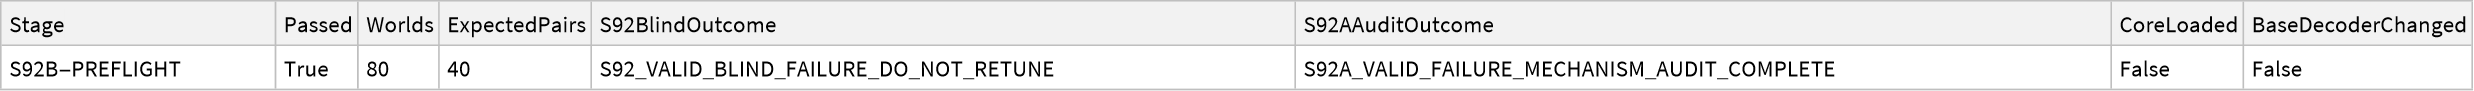

In [320]:
ClearAll[FileSHA256Hex92B];
FileSHA256Hex92B[path_String]:=IntegerString[FileHash[path,"SHA256"],16,64];

projectDirectory92B=Directory[];
archivePath92B=FileNameJoin[{projectDirectory92B,"artifacts",
"TCCT_S92_FailureAuditWorlds.json"}];
archiveManifestPath92B=FileNameJoin[{projectDirectory92B,"artifacts",
"TCCT_S92_FailureAuditWorlds_Manifest.json"}];
workspaceRuntimePath92B=FileNameJoin[{projectDirectory92B,
"TCCT_S92B_PairedContrastDecoderRuntime.wl"}];
baseDecoderRuntimePath92B="E:/engine_wolf/TCCT_S87D_FrozenDecoderRuntime.wl";
baseDecoderCandidatePath92B="E:/engine_wolf/TCCT_S87D_FrozenWorldMultisetDecoder.wxf";
s92CertificatePath92B="E:/engine_wolf/TCCT_S92_BlindResultCertificate.json";
s92aCertificatePath92B="E:/engine_wolf/TCCT_S92A_FailureAuditCertificate.json";
s92bCandidatePath="E:/engine_wolf/TCCT_S92B_FrozenPairedContrastDecoder.wxf";
s92bRuntimePath="E:/engine_wolf/TCCT_S92B_PairedContrastDecoderRuntime.wl";
s92bCertificatePath="E:/engine_wolf/TCCT_S92B_PairedContrastDecoderCertificate.json";

expectedArchiveFileHash92B=
"dfe57246390b8bef52e2bf2bd98e01ba4fecc88091d269067bfb04f2b1b9d3bd";
expectedArchiveManifestFileHash92B=
"4c115bd1f45e407d6bc534a0236b65d150b37359e2afdad7bbe6fddc384ccb09";
expectedArchivePayloadHash92B=
"392721c25845bd8c4c40dd012fafef4ddb9936c68caae697ac5456d8a2bd07e7";
expectedBaseCandidateFileHash92B=
"82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91";
expectedBaseCandidateHash92B=
"703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe";
expectedBaseRuntimeFileHash92B=
"7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee";
expectedS92CertificateFileHash92B=
"22cec6972285fe127e66d740bfdbbf27fbabaa097cb24cc0bbc7196da004a40b";
expectedS92ACertificateFileHash92B=
"7d21e30f1da322f2a078cc5c0fe9cf44cec5cfac0cc18f0020517a76ad897309";
expectedS92ProtocolHash92B=
"4e7117970c3e5c4315fb4953364b632404566258a718c7807c8819ba3d30b6bb";
expectedS92BlindResultHash92B=
"a715ad1366f300a3e149c9f1df83c8e81744a7583678482900ed8736e4fc2273";
expectedS92AAuditResultHash92B=
"976a850af3f591b8766f0aeb3439b70678b051e91ef0452c1df77dfebf0fd9f9";
expectedWorkspaceRuntimeFileHash92B="74a926b8efccaddbd1dd07373ac35a93bc53e9fb08cc456ce1adb6a006d333c6";

requiredFiles92B={archivePath92B,archiveManifestPath92B,
workspaceRuntimePath92B,baseDecoderRuntimePath92B,baseDecoderCandidatePath92B,
s92CertificatePath92B,s92aCertificatePath92B};
If[!And@@(FileExistsQ/@requiredFiles92B),
Print["S92B aborted: one or more locked inputs are missing."];
Dataset[AssociationThread[requiredFiles92B,FileExistsQ/@requiredFiles92B]];
Abort[]];
If[Or@@(FileExistsQ/@{s92bCandidatePath,s92bRuntimePath,s92bCertificatePath}),
Print["S92B aborted: a prior candidate, runtime, or certificate exists. Preserve it."];
Dataset[AssociationThread[{s92bCandidatePath,s92bRuntimePath,s92bCertificatePath},
FileExistsQ/@{s92bCandidatePath,s92bRuntimePath,s92bCertificatePath}]];
Abort[]];

archiveHashBefore92B=FileSHA256Hex92B[archivePath92B];
archiveManifestHashBefore92B=FileSHA256Hex92B[archiveManifestPath92B];
workspaceRuntimeHashBefore92B=FileSHA256Hex92B[workspaceRuntimePath92B];
baseRuntimeHashBefore92B=FileSHA256Hex92B[baseDecoderRuntimePath92B];
baseCandidateHashBefore92B=FileSHA256Hex92B[baseDecoderCandidatePath92B];
s92CertificateHashBefore92B=FileSHA256Hex92B[s92CertificatePath92B];
s92aCertificateHashBefore92B=FileSHA256Hex92B[s92aCertificatePath92B];

archive92B=Quiet@Check[Import[archivePath92B,"RawJSON"],$Failed];
archiveManifest92B=Quiet@Check[Import[archiveManifestPath92B,"RawJSON"],$Failed];
s92Certificate92B=Quiet@Check[Import[s92CertificatePath92B,"RawJSON"],$Failed];
s92aCertificate92B=Quiet@Check[Import[s92aCertificatePath92B,"RawJSON"],$Failed];
If[!And@@(AssociationQ/@{archive92B,archiveManifest92B,
s92Certificate92B,s92aCertificate92B}),
Print["S92B aborted: a locked JSON input could not be imported."];Abort[]];

Get[baseDecoderRuntimePath92B];
baseDecoder92B=Quiet@Check[
TCCTLoadFrozenDecoderS87D[baseDecoderCandidatePath92B],$Failed];
If[!AssociationQ[baseDecoder92B],
Print["S92B aborted: base S87D decoder integrity check failed."];Abort[]];

rows92B=Lookup[archive92B,"Rows",$Failed];
vectors92B=If[ListQ[rows92B],Lookup[rows92B,"FeatureVector",$Failed],$Failed];
targets92B=If[ListQ[rows92B],Lookup[rows92B,"Target",$Failed],$Failed];

preflightPassed92B=And[
SameQ[archiveHashBefore92B,expectedArchiveFileHash92B],
SameQ[archiveManifestHashBefore92B,expectedArchiveManifestFileHash92B],
SameQ[workspaceRuntimeHashBefore92B,expectedWorkspaceRuntimeFileHash92B],
SameQ[baseRuntimeHashBefore92B,expectedBaseRuntimeFileHash92B],
SameQ[baseCandidateHashBefore92B,expectedBaseCandidateFileHash92B],
SameQ[s92CertificateHashBefore92B,expectedS92CertificateFileHash92B],
SameQ[s92aCertificateHashBefore92B,expectedS92ACertificateFileHash92B],
SameQ[archive92B["ArchivePayloadHash"],expectedArchivePayloadHash92B],
SameQ[archiveManifest92B["ArchivePayloadHash"],expectedArchivePayloadHash92B],
SameQ[s92Certificate92B["ProtocolHash"],expectedS92ProtocolHash92B],
SameQ[s92Certificate92B["BlindResultHash"],expectedS92BlindResultHash92B],
SameQ[s92Certificate92B["Outcome"],"S92_VALID_BLIND_FAILURE_DO_NOT_RETUNE"],
SameQ[s92aCertificate92B["AuditResultHash"],expectedS92AAuditResultHash92B],
SameQ[s92aCertificate92B["Outcome"],
"S92A_VALID_FAILURE_MECHANISM_AUDIT_COMPLETE"],
SameQ[baseDecoder92B["CandidateHash"],expectedBaseCandidateHash92B],
ListQ[rows92B],SameQ[Length[rows92B],80],
ListQ[vectors92B],SameQ[Length[vectors92B],80],
And@@(VectorQ[#,IntegerQ]&&Length[#]===27&/@vectors92B),
SameQ[Counts[targets92B],<|"Continue"->40,"Stop"->40|>],
SameQ[DeleteDuplicates[Lookup[rows92B,"Cardinality"]],{{1,1,0}}]
];
If[!TrueQ[preflightPassed92B],
Print["S92B aborted: locked-input preflight failed."];Abort[]];

Dataset[{<|"Stage"->"S92B-PREFLIGHT","Passed"->preflightPassed92B,
"Worlds"->Length[rows92B],"ExpectedPairs"->40,
"S92BlindOutcome"->s92Certificate92B["Outcome"],
"S92AAuditOutcome"->s92aCertificate92B["Outcome"],
"CoreLoaded"->False,"BaseDecoderChanged"->False|>}]

Dataset[{<|Stage -> S92B, Name -> PairedContrastDecoderTrainingAndFreeze, 
 
>     EvaluationType -> RevealedS92OuterDecoderDevelopment, BlindTest -> False, 
 
>     UsesRevealedS92Labels -> True, S92MayNotBeReusedAsBlind -> True, 
 
>     Architecture -> OrderedMatchedWorldPairModularContrast, 
 
>     BaseFeatureRuntime -> UnchangedS87D27DimensionalVector, 
 
>     CandidateContrastPositions -> 
 
>      {3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, 
 
>     ForbiddenContrastPositions -> {1, 2, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27}, 
 
>     Modulus -> 33, DecoderFamily -> ExactLearnedDeltaPolicy, 
 
>     PairKey -> {Topology, Depth, Answer}, 
 
>     OrientationTargets -> {FirstContinue, FirstStop}, 
 
>     SelectionFolds -> LeaveOneAnswerOut, 
 
>     AnswerHoldouts -> {1, 2, 3, 4, 5, 6, 7, 8, 9, 10}, 
 
>     SelectionRequirement -> AllAnswerFoldsPerfectAndFullTrainingPerfect, 
 
>     TieBreak -> {ShortestPolicy, LowestFeaturePosition}, 
 
>     SecondaryRegressionAxes -> {Topology, Depth}, 
 
>     RequiresTwoMatchedAlternativeWorldsAtInference -> True, 
 
>     SingleWorldDecoderReplaced -> False, BaseFrozenS87DDecoderPreserved -> True, 
 
>     TrainingRun -> True, CandidateSearchRun -> True, HyperparameterSearchRun -> False, 
 
>     RetuningOldDecoder -> False, CoreLoaded -> False, CoreEditApplied -> False, 
 
>     FeatureRuntimeEditApplied -> False, CanonicalizerEditApplied -> False, 
 
>     InterventionRuleEditApplied -> False, DeduplicationMechanismEditApplied -> False, 
 
>     UndirectedFreezeMechanismEditApplied -> False, S93DesignedBeforeFreeze -> False, 
 
>     S93DataAvailableBeforeFreeze -> False, S93BlindTestRun -> False, 
 
>     MayClaimNewBlindGeneralization -> False, 
 
>     ProtocolHash -> decbe5ac7cd99bc31eee33712245f221e8c90d5a046ec3076f0f933e2fde777f|>}
 
>    , TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 
 
>     38], 1], <||>]
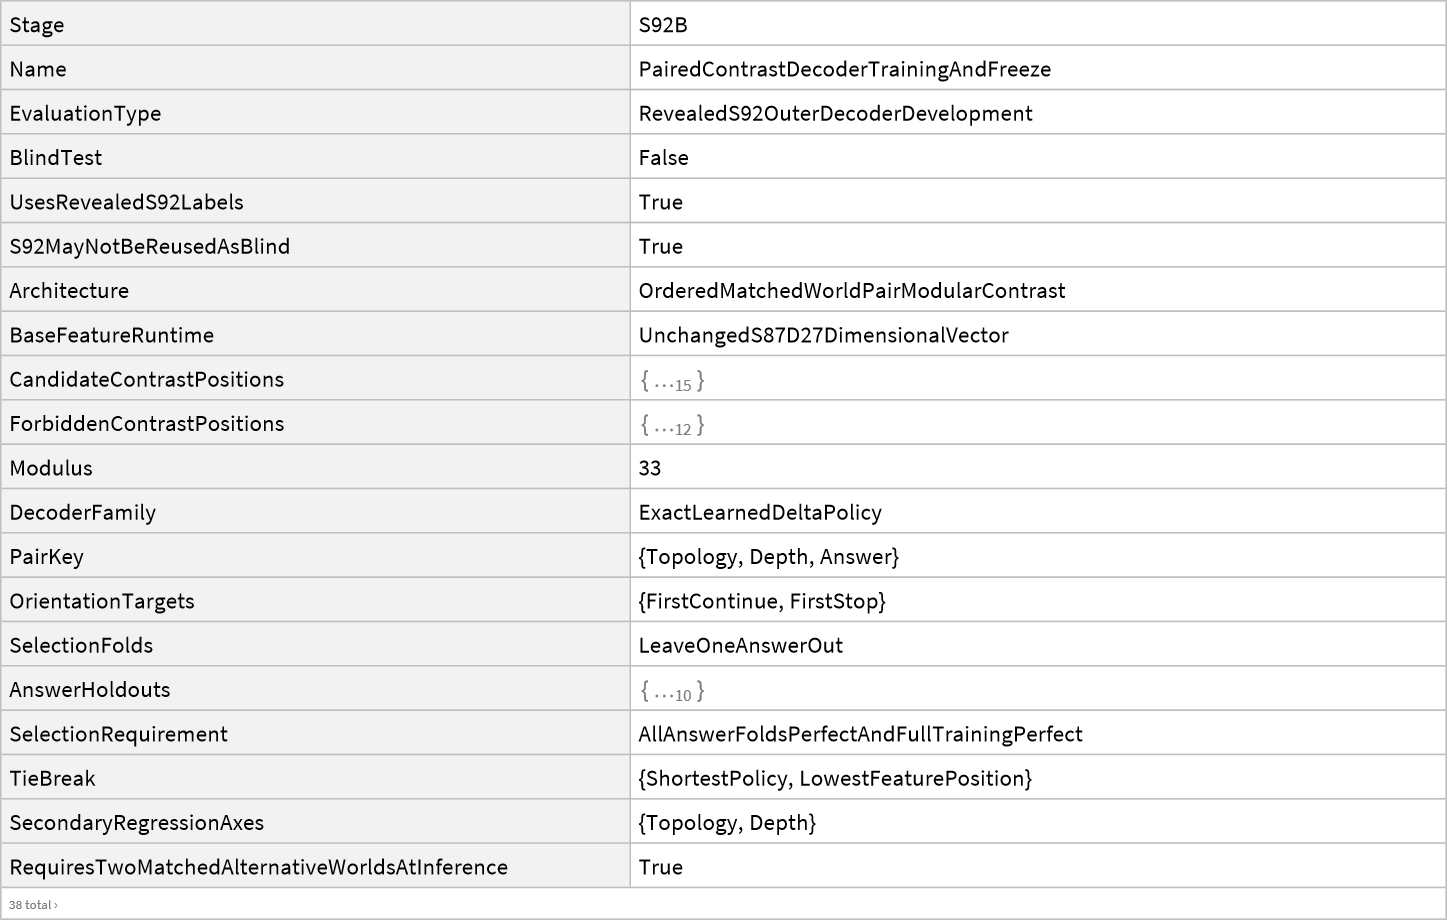

In [373]:
ClearAll[PairKey92B,BuildPairs92B,PairDelta92B,BuildExamples92B,
LearnDeltaPolicy92B,PredictDeltaPolicy92B,ScoreExamples92B,
EvaluateFold92B,EvaluatePosition92B,PolicyRules92B,EvaluateAxis92B];

candidatePositions92B=Range[3,17];
modulus92B=33;
answerHoldouts92B=Range[10];

protocol92B=<|
"Stage"->"S92B","Name"->"PairedContrastDecoderTrainingAndFreeze",
"EvaluationType"->"RevealedS92OuterDecoderDevelopment",
"BlindTest"->False,"UsesRevealedS92Labels"->True,
"S92MayNotBeReusedAsBlind"->True,
"Architecture"->"OrderedMatchedWorldPairModularContrast",
"BaseFeatureRuntime"->"UnchangedS87D27DimensionalVector",
"CandidateContrastPositions"->candidatePositions92B,
"ForbiddenContrastPositions"->{1,2,18,19,20,21,22,23,24,25,26,27},
"Modulus"->modulus92B,
"DecoderFamily"->"ExactLearnedDeltaPolicy",
"PairKey"->{"Topology","Depth","Answer"},
"OrientationTargets"->{"FirstContinue","FirstStop"},
"SelectionFolds"->"LeaveOneAnswerOut",
"AnswerHoldouts"->answerHoldouts92B,
"SelectionRequirement"->"AllAnswerFoldsPerfectAndFullTrainingPerfect",
"TieBreak"->{"ShortestPolicy","LowestFeaturePosition"},
"SecondaryRegressionAxes"->{"Topology","Depth"},
"RequiresTwoMatchedAlternativeWorldsAtInference"->True,
"SingleWorldDecoderReplaced"->False,
"BaseFrozenS87DDecoderPreserved"->True,
"TrainingRun"->True,"CandidateSearchRun"->True,
"HyperparameterSearchRun"->False,"RetuningOldDecoder"->False,
"CoreLoaded"->False,"CoreEditApplied"->False,
"FeatureRuntimeEditApplied"->False,
"CanonicalizerEditApplied"->False,
"InterventionRuleEditApplied"->False,
"DeduplicationMechanismEditApplied"->False,
"UndirectedFreezeMechanismEditApplied"->False,
"S93DesignedBeforeFreeze"->False,
"S93DataAvailableBeforeFreeze"->False,
"S93BlindTestRun"->False,
"MayClaimNewBlindGeneralization"->False
|>;
protocolHashBeforeTraining92B=Hash[Normal[protocol92B],"SHA256","HexString"];
Dataset[{Append[protocol92B,"ProtocolHash"->protocolHashBeforeTraining92B]}]

Dataset[{<|Position -> 3, Feature -> FirstCoordinateTotal, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 10, PerfectFolds -> 10, WorstFoldScore -> 8, FullScore -> 80, 
 
>     FullCases -> 80, FullUnknown -> 0, PolicySize -> 2|>, 
 
>    <|Position -> 4, Feature -> SecondCoordinateTotal, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 10, PerfectFolds -> 6, WorstFoldScore -> 0, FullScore -> 80, 
 
>     FullCases -> 80, FullUnknown -> 0, PolicySize -> 12|>, 
 
>    <|Position -> 5, Feature -> FirstCoordinateSquareTotal, Examples -> 80, 
 
>     Folds -> 10, ValidFolds -> 0, PerfectFolds -> 0, WorstFoldScore -> 0, 
 
>     FullScore -> 0, FullCases -> 80, FullUnknown -> 80, PolicySize -> 0|>, 
 
>    <|Position -> 6, Feature -> SecondCoordinateSquareTotal, Examples -> 80, 
 
>     Folds -> 10, ValidFolds -> 0, PerfectFolds -> 0, WorstFoldScore -> 0, 
 
>     FullScore -> 0, FullCases -> 80, FullUnknown -> 80, PolicySize -> 0|>, 
 
>    <|Position -> 7, Feature -> FirstCoordinateMinimum, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 10, PerfectFolds -> 10, WorstFoldScore -> 8, FullScore -> 80, 
 
>     FullCases -> 80, FullUnknown -> 0, PolicySize -> 2|>, 
 
>    <|Position -> 8, Feature -> FirstCoordinateMaximum, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 10, PerfectFolds -> 10, WorstFoldScore -> 8, FullScore -> 80, 
 
>     FullCases -> 80, FullUnknown -> 0, PolicySize -> 2|>, 
 
>    <|Position -> 9, Feature -> SecondCoordinateMinimum, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 10, PerfectFolds -> 6, WorstFoldScore -> 0, FullScore -> 80, 
 
>     FullCases -> 80, FullUnknown -> 0, PolicySize -> 12|>, 
 
>    <|Position -> 10, Feature -> SecondCoordinateMaximum, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 10, PerfectFolds -> 6, WorstFoldScore -> 0, FullScore -> 80, 
 
>     FullCases -> 80, FullUnknown -> 0, PolicySize -> 12|>, 
 
>    <|Position -> 11, Feature -> DeltaMod33Total, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 10, PerfectFolds -> 6, WorstFoldScore -> 0, FullScore -> 80, 
 
>     FullCases -> 80, FullUnknown -> 0, PolicySize -> 12|>, 
 
>    <|Position -> 12, Feature -> SumMod33Total, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 10, PerfectFolds -> 6, WorstFoldScore -> 0, FullScore -> 80, 
 
>     FullCases -> 80, FullUnknown -> 0, PolicySize -> 12|>, 
 
>    <|Position -> 13, Feature -> ProductMod33Total, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 1, PerfectFolds -> 0, WorstFoldScore -> 0, FullScore -> 0, 
 
>     FullCases -> 80, FullUnknown -> 80, PolicySize -> 0|>, 
 
>    <|Position -> 14, Feature -> EqualCoordinateCount, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 0, PerfectFolds -> 0, WorstFoldScore -> 0, FullScore -> 0, 
 
>     FullCases -> 80, FullUnknown -> 80, PolicySize -> 0|>, 
 
>    <|Position -> 15, Feature -> FirstLessCount, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 0, PerfectFolds -> 0, WorstFoldScore -> 0, FullScore -> 0, 
 
>     FullCases -> 80, FullUnknown -> 80, PolicySize -> 0|>, 
 
>    <|Position -> 16, Feature -> FirstGreaterCount, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 0, PerfectFolds -> 0, WorstFoldScore -> 0, FullScore -> 0, 
 
>     FullCases -> 80, FullUnknown -> 80, PolicySize -> 0|>, 
 
>    <|Position -> 17, Feature -> CoordinateDistanceTotal, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 0, PerfectFolds -> 0, WorstFoldScore -> 0, FullScore -> 0, 
 
>     FullCases -> 80, FullUnknown -> 80, PolicySize -> 0|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Position, Feature, Examples, Folds, ValidFolds, 
 
>      PerfectFolds, WorstFoldScore, FullScore, FullCases, FullUnknown, PolicySize}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer
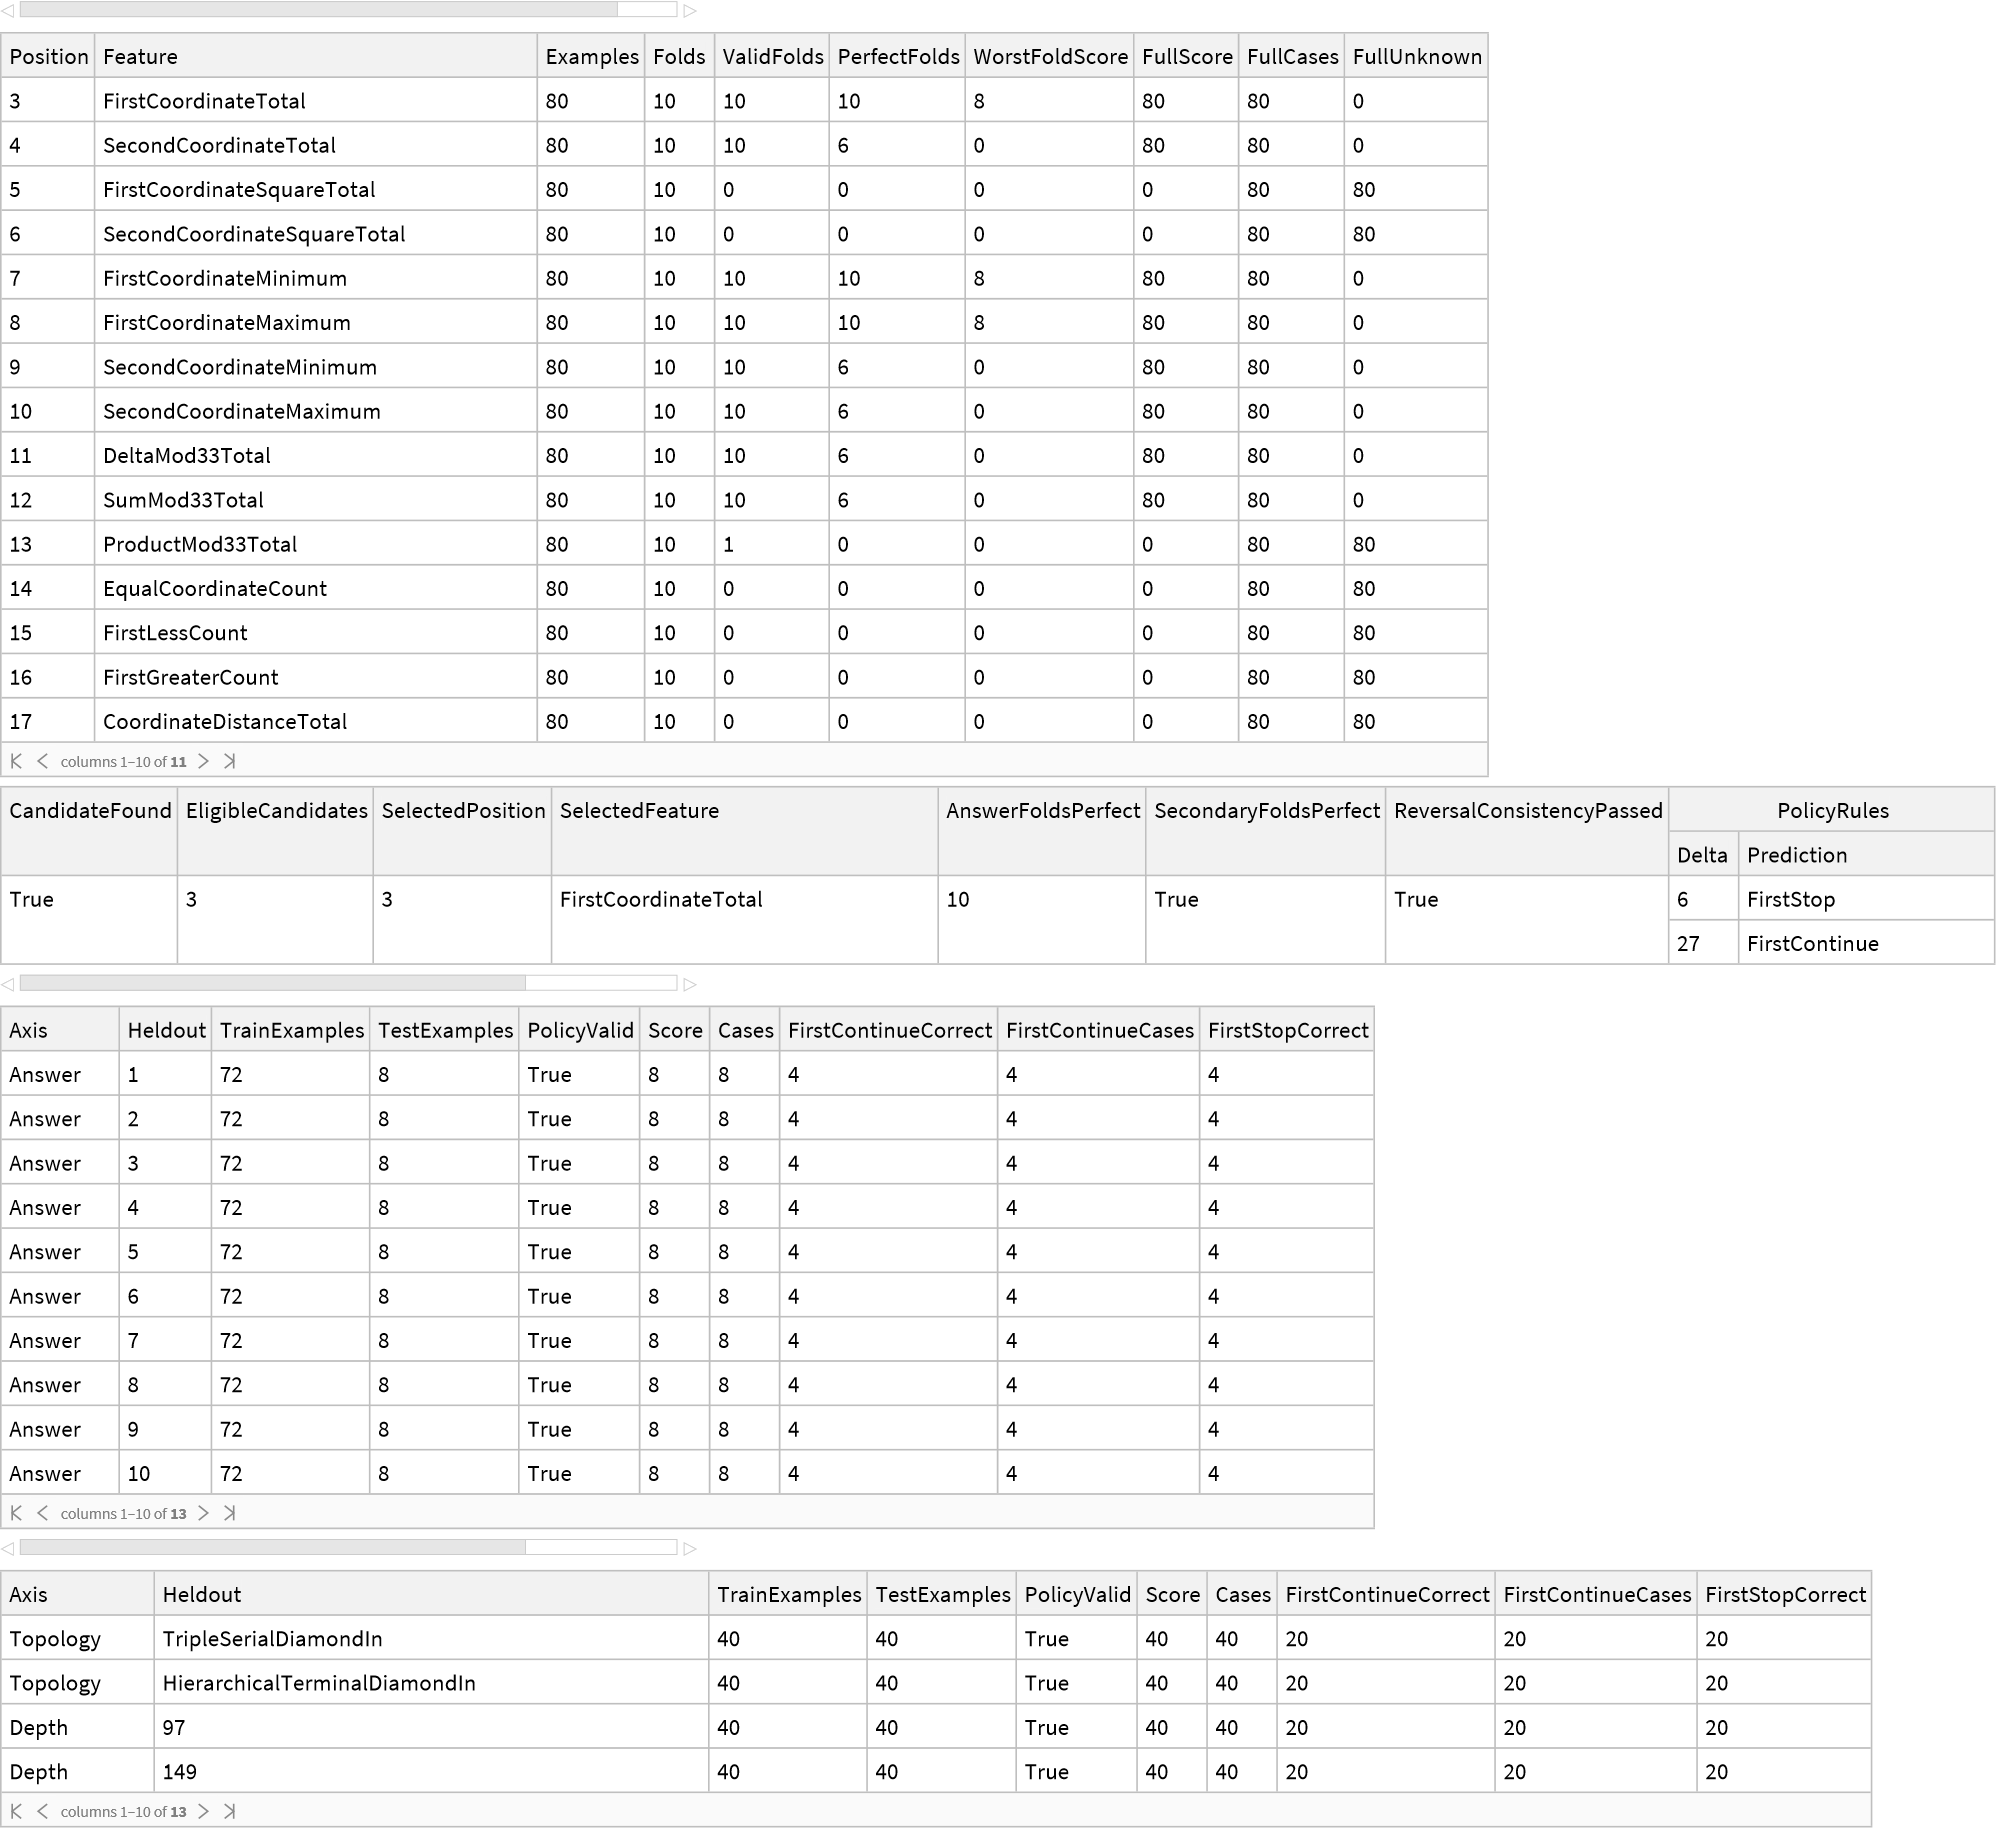

In [384]:
PairKey92B[row_Association]:={row["Topology"],row["Depth"],row["Answer"]};
BuildPairs92B[rows_List]:=Module[{continueRows,stopRows,keys},
continueRows=Select[rows,SameQ[#1["Target"],"Continue"]&];
stopRows=Select[rows,SameQ[#1["Target"],"Stop"]&];
keys=PairKey92B/@continueRows;
Map[Function[key,<|"Key"->key,
"Topology"->key[[1]],"Depth"->key[[2]],"Answer"->key[[3]],
"Continue"->SelectFirst[continueRows,SameQ[PairKey92B[#],key]&,$Failed],
"Stop"->SelectFirst[stopRows,SameQ[PairKey92B[#],key]&,$Failed]|>],keys]
];
pairedWorlds92B=BuildPairs92B[rows92B];
pairedWorldsValid92B=And[SameQ[Length[pairedWorlds92B],40],
SameQ[Length[DeleteDuplicates[Lookup[pairedWorlds92B,"Key"]]],40],
And@@Map[Function[pair,AssociationQ[pair["Continue"]]&&
AssociationQ[pair["Stop"]]&&
SameQ[pair["Continue"]["Cardinality"],{1,1,0}]&&
SameQ[pair["Stop"]["Cardinality"],{1,1,0}]],pairedWorlds92B]];
If[!TrueQ[pairedWorldsValid92B],
Print["S92B aborted: paired S92 archive structure is invalid."];Abort[]];

PairDelta92B[first_List,second_List,position_Integer]:=
Mod[first[[position]]-second[[position]],modulus92B];
BuildExamples92B[position_Integer]:=Flatten[Map[Function[pair,With[
{c=pair["Continue"],s=pair["Stop"]},{
<|"Topology"->pair["Topology"],"Depth"->pair["Depth"],
"Answer"->pair["Answer"],
"Delta"->PairDelta92B[c["FeatureVector"],s["FeatureVector"],position],
"Target"->"FirstContinue"|>,
<|"Topology"->pair["Topology"],"Depth"->pair["Depth"],
"Answer"->pair["Answer"],
"Delta"->PairDelta92B[s["FeatureVector"],c["FeatureVector"],position],
"Target"->"FirstStop"|>}]],pairedWorlds92B],1];

LearnDeltaPolicy92B[examples_List]:=Module[{groups,targetSets},
groups=GatherBy[examples,#1["Delta"]&];
targetSets=DeleteDuplicates[Lookup[#,"Target"]]&/@groups;
If[AnyTrue[targetSets,Length[#]=!=1&],Return[$Failed]];
Association[Map[Function[group,
First[Lookup[group,"Delta"]]->First[Lookup[group,"Target"]]],groups]]
];
PredictDeltaPolicy92B[policy_Association,examples_List]:=
Lookup[policy,Lookup[examples,"Delta"],"Unknown"];
ScoreExamples92B[examples_List,predictions_List]:=Module[{targets},
targets=Lookup[examples,"Target"];
<|"Score"->Count[MapThread[SameQ,{targets,predictions}],True],
"Cases"->Length[examples],
"FirstContinueCorrect"->Count[Pick[predictions,targets,"FirstContinue"],
"FirstContinue"],
"FirstContinueCases"->Count[targets,"FirstContinue"],
"FirstStopCorrect"->Count[Pick[predictions,targets,"FirstStop"],"FirstStop"],
"FirstStopCases"->Count[targets,"FirstStop"],
"Unknown"->Count[predictions,"Unknown"]|>
];
EvaluateFold92B[examples_List,axis_String,heldout_]:=Module[
{train,test,policy,predictions,score},
train=Select[examples,!SameQ[#1[axis],heldout]&];
test=Select[examples,SameQ[#1[axis],heldout]&];
policy=LearnDeltaPolicy92B[train];
predictions=If[AssociationQ[policy],PredictDeltaPolicy92B[policy,test],
ConstantArray["Unknown",Length[test]]];
score=ScoreExamples92B[test,predictions];
Join[<|"Axis"->axis,"Heldout"->heldout,"TrainExamples"->Length[train],
"TestExamples"->Length[test],"PolicyValid"->AssociationQ[policy]|>,score,
<|"Perfect"->SameQ[score["Score"],score["Cases"]]|>]
];
EvaluatePosition92B[position_Integer]:=Module[
{examples,foldRows,fullPolicy,fullPredictions,fullScore},
examples=BuildExamples92B[position];
foldRows=EvaluateFold92B[examples,"Answer",#]&/@answerHoldouts92B;
fullPolicy=LearnDeltaPolicy92B[examples];
fullPredictions=If[AssociationQ[fullPolicy],
PredictDeltaPolicy92B[fullPolicy,examples],ConstantArray["Unknown",Length[examples]]];
fullScore=ScoreExamples92B[examples,fullPredictions];
<|"Position"->position,"Feature"->TCCTFeatureNamesS87D[][[position]],
"Examples"->Length[examples],"Folds"->Length[foldRows],
"ValidFolds"->Count[Lookup[foldRows,"PolicyValid"],True],
"PerfectFolds"->Count[Lookup[foldRows,"Perfect"],True],
"WorstFoldScore"->Min[Lookup[foldRows,"Score"]],
"FullScore"->fullScore["Score"],"FullCases"->fullScore["Cases"],
"FullUnknown"->fullScore["Unknown"],
"PolicySize"->If[AssociationQ[fullPolicy],Length[fullPolicy],0],
"FoldRows"->foldRows,"FullPolicy"->fullPolicy|>
];
positionResults92B=EvaluatePosition92B/@candidatePositions92B;
eligibleResults92B=Select[positionResults92B,And[
SameQ[#1["ValidFolds"],10],SameQ[#1["PerfectFolds"],10],
SameQ[#1["FullScore"],#1["FullCases"]],SameQ[#1["FullUnknown"],0],
AssociationQ[#1["FullPolicy"]],
Sort[DeleteDuplicates[Values[#1["FullPolicy"]]]]===
{"FirstContinue","FirstStop"}]&];
candidateFound92B=Length[eligibleResults92B]>0;
selectedResult92B=If[candidateFound92B,
First@SortBy[eligibleResults92B,{#1["PolicySize"]&,#1["Position"]&}],$Failed];

PolicyRules92B[policy_Association]:=Map[
Function[rule,<|"Delta"->First[rule],"Prediction"->Last[rule]|>],
SortBy[Normal[policy],First]];
EvaluateAxis92B[position_Integer,axis_String]:=Module[{examples,values},
examples=BuildExamples92B[position];values=DeleteDuplicates[Lookup[examples,axis]];
EvaluateFold92B[examples,axis,#]&/@values];

secondaryFoldRows92B=If[candidateFound92B,
Join[EvaluateAxis92B[selectedResult92B["Position"],"Topology"],
EvaluateAxis92B[selectedResult92B["Position"],"Depth"]],{}];
secondaryFoldsPerfect92B=candidateFound92B&&
And@@(TrueQ[Lookup[#,"Perfect",False]]&/@secondaryFoldRows92B);
selectedExamples92B=If[candidateFound92B,
BuildExamples92B[selectedResult92B["Position"]],{}];
selectedPolicyRules92B=If[candidateFound92B,
PolicyRules92B[selectedResult92B["FullPolicy"]],{}];
reversalConsistencyPassed92B=candidateFound92B&&
SameQ[Count[Lookup[selectedExamples92B,"Target"],"FirstContinue"],40]&&
SameQ[Count[Lookup[selectedExamples92B,"Target"],"FirstStop"],40]&&
SameQ[selectedResult92B["FullScore"],80];

Column[{
Dataset[Map[KeyDrop[#,{"FoldRows","FullPolicy"}]&,positionResults92B]],
Dataset[{<|"CandidateFound"->candidateFound92B,
"EligibleCandidates"->Length[eligibleResults92B],
"SelectedPosition"->If[candidateFound92B,selectedResult92B["Position"],"NONE"],
"SelectedFeature"->If[candidateFound92B,selectedResult92B["Feature"],"NONE"],
"AnswerFoldsPerfect"->If[candidateFound92B,selectedResult92B["PerfectFolds"],0],
"SecondaryFoldsPerfect"->secondaryFoldsPerfect92B,
"ReversalConsistencyPassed"->reversalConsistencyPassed92B,
"PolicyRules"->selectedPolicyRules92B|>}],
Dataset[If[candidateFound92B,selectedResult92B["FoldRows"],{}]],
Dataset[secondaryFoldRows92B]
}]

Dataset[{<|Stage -> S92B, Name -> PairedContrastDecoderTrainingAndFreeze, 
 
>     EvaluationType -> RevealedS92OuterDecoderDevelopment, BlindTest -> False, 
 
>     ProtocolHash -> decbe5ac7cd99bc31eee33712245f221e8c90d5a046ec3076f0f933e2fde777f, 
 
>     S92ArchiveFileHash -> 
 
>      dfe57246390b8bef52e2bf2bd98e01ba4fecc88091d269067bfb04f2b1b9d3bd, 
 
>     S92ArchivePayloadHash -> 
 
>      392721c25845bd8c4c40dd012fafef4ddb9936c68caae697ac5456d8a2bd07e7, 
 
>     S92CertificateFileHash -> 
 
>      22cec6972285fe127e66d740bfdbbf27fbabaa097cb24cc0bbc7196da004a40b, 
 
>     S92ACertificateFileHash -> 
 
>      7d21e30f1da322f2a078cc5c0fe9cf44cec5cfac0cc18f0020517a76ad897309, 
 
>     BaseFrozenCandidateHash -> 
 
>      703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     BaseFrozenCandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     BaseFrozenRuntimeFileHash -> 
 
>      7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee, 
 
>     CandidatePositionsEvaluated -> 15, Pairs -> 40, OrientedExamples -> 80, 
 
>     CandidateFound -> True, EligibleCandidates -> 3, SelectedPosition -> 3, 
 
>     SelectedFeature -> FirstCoordinateTotal, 
 
>     SelectedPolicyRules -> 
 
>      {<|Delta -> 6, Prediction -> FirstStop|>, 
 
>       <|Delta -> 27, Prediction -> FirstContinue|>}, AnswerFolds -> 10, 
 
>     AnswerPerfectFolds -> 10, FullTrainingScore -> 80, FullTrainingCases -> 80, 
 
>     SecondaryRegressionFolds -> 4, SecondaryFoldsPerfect -> True, 
 
>     ReversalConsistencyPassed -> True, ResearchValidityPassed -> True, 
 
>     FreezeEligible -> True, CandidateExported -> True, RuntimeExported -> True, 
 
>     RoundTripPassed -> True, FreezeValidityPassed -> True, 
 
>     FrozenCandidateHash -> 
 
>      540229035af53b2e014592fd7e7d2eab70b374844d9a73000026325c6cd39a1c, 
 
>     OriginalFrozenModelChanged -> False, BaseFrozenS87DDecoderChanged -> False, 
 
>     CoreLoaded -> False, CoreChanged -> False, FeatureRuntimeChanged -> False, 
 
>     CanonicalizerChanged -> False, InterventionCoreChanged -> False, 
 
>     DeduplicationMechanismChanged -> False, UndirectedFreezeMechanismChanged -> False, 
 
>     TrainingRun -> True, CandidateSearchRun -> True, HyperparameterSearchRun -> False, 
 
>     OldDecoderRetuned -> False, RequiresTwoMatchedAlternativeWorldsAtInference -> 
 
>      True, MayClaimSingleWorldDecoderFixed -> False, 
 
>     MayClaimNewBlindGeneralization -> False, S93DesignedBeforeFreeze -> False, 
 
>     S93BlindTestRun -> False, CertificateResultHash -> 
 
>      0e3301be5d06af42d7e44ddb0e2b02e377fc378fcfefe98d928db875fc6c7373, 
 
>     Outcome -> S92B_PAIRED_CONTRAST_DECODER_FROZEN_FOR_S93, 
 
>     SuggestedNextStage -> 
 
>      S93_PREREGISTER_NEW_PAIRED_COUNTERFACTUAL_GRAMMAR_THEN_BLIND_TEST|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 55], 
 
>    1], <||>]
Dataset[{<|Position -> 3, Feature -> FirstCoordinateTotal, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 10, PerfectFolds -> 10, WorstFoldScore -> 8, FullScore -> 80, 
 
>     FullCases -> 80, FullUnknown -> 0, PolicySize -> 2|>, 
 
>    <|Position -> 4, Feature -> SecondCoordinateTotal, Examples -> 80, Folds -> 10, 
 
>     ValidFolds -> 10, PerfectFolds -> 6, WorstFoldScore -> 0, FullScore -> 80, 
 
>     FullCases -> 80, FullUnknown -> 0, PolicySize -> 12|>, 
 
>    <|Position -> 5, Feature -> FirstCoordinateSquareTotal, Examples -> 80, 
 
>     Folds -> 10, ValidFolds -> 0, PerfectFolds -> 0, WorstFoldScore -> 0, 
 
>     FullScore -> 0, FullCases -> 80, FullUnknown -> 80, PolicySize -> 0|>, 
 
>    <|Position -> 6, Feature -> SecondCoordinateSquareTotal, Examples -> 80, 
 
>     Folds -> 10, ValidFolds -> 0, PerfectFolds -> 0, WorstFoldScore -> 0, 
 
>     FullScore -> 0, FullCases -> 80, FullUnknown -> 80, PolicySize -> 0|>, 
 
>    <|Position -> 7, Feature -> FirstCoordinateMinimum, Examples -> 80, Fol
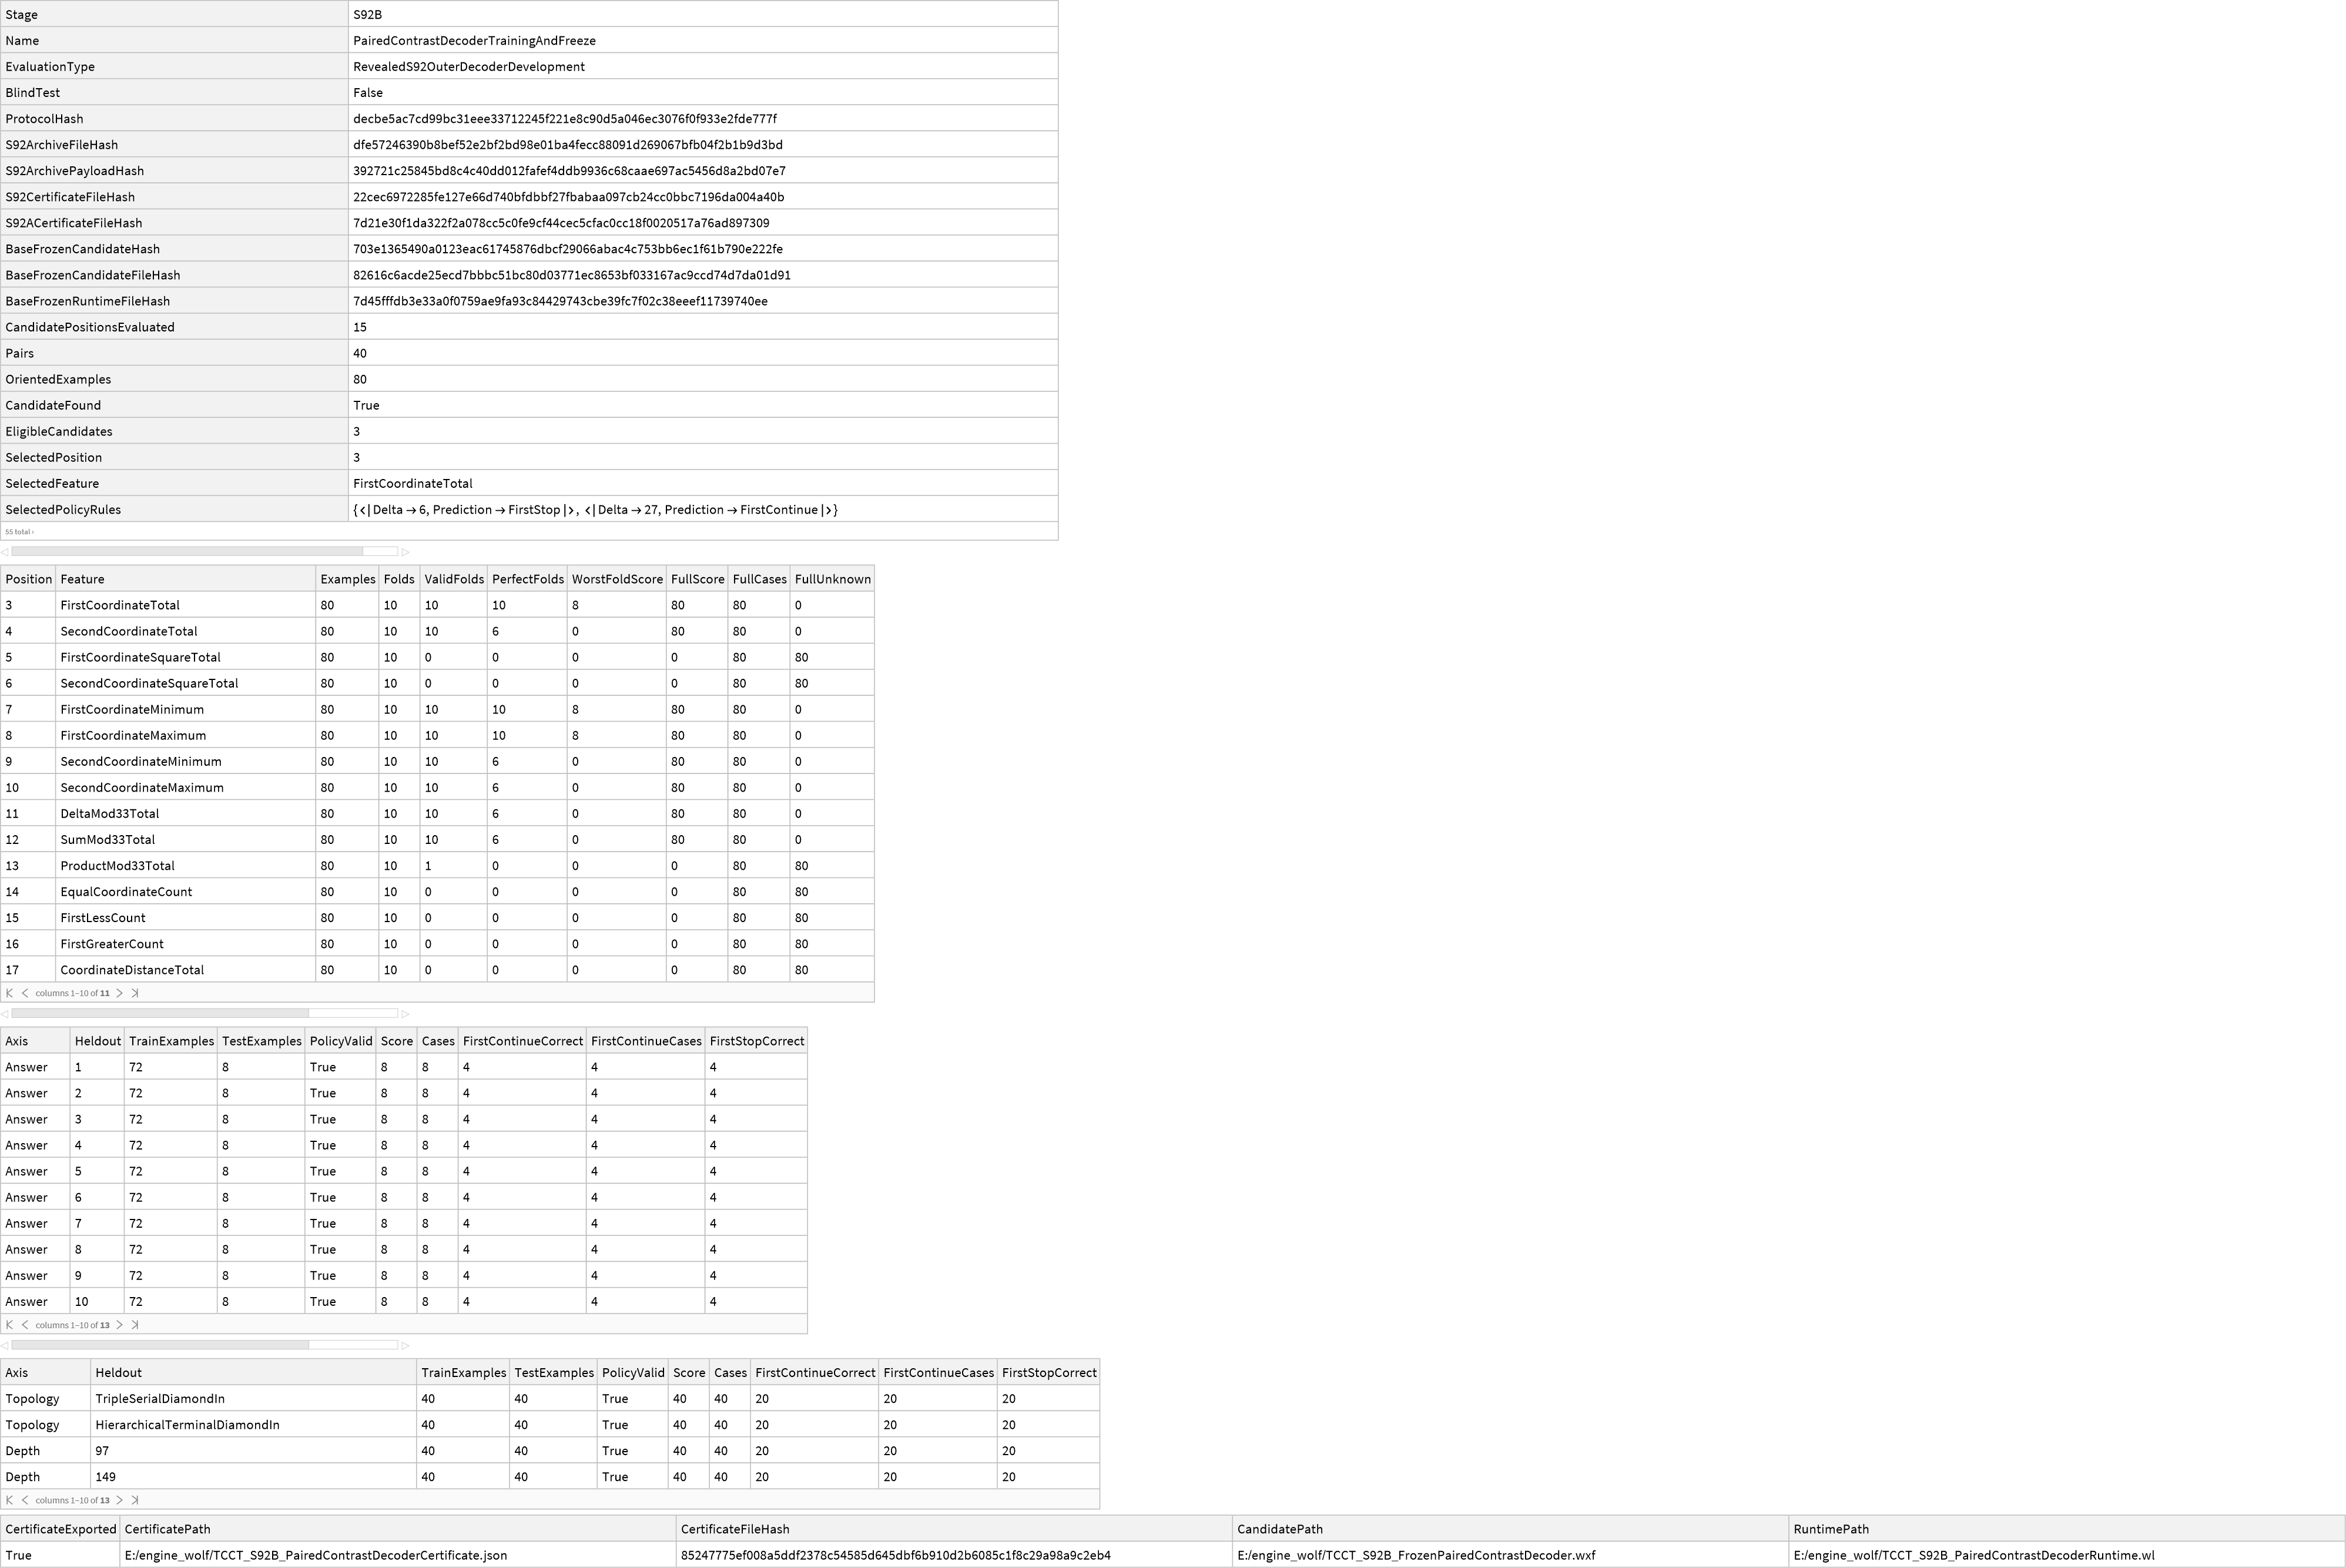

In [408]:
protocolHashAfterTraining92B=Hash[Normal[protocol92B],"SHA256","HexString"];
archiveHashAfter92B=FileSHA256Hex92B[archivePath92B];
archiveManifestHashAfter92B=FileSHA256Hex92B[archiveManifestPath92B];
workspaceRuntimeHashAfter92B=FileSHA256Hex92B[workspaceRuntimePath92B];
baseRuntimeHashAfter92B=FileSHA256Hex92B[baseDecoderRuntimePath92B];
baseCandidateHashAfter92B=FileSHA256Hex92B[baseDecoderCandidatePath92B];
s92CertificateHashAfter92B=FileSHA256Hex92B[s92CertificatePath92B];
s92aCertificateHashAfter92B=FileSHA256Hex92B[s92aCertificatePath92B];

researchValidityPassed92B=And[TrueQ[preflightPassed92B],
TrueQ[pairedWorldsValid92B],SameQ[Length[positionResults92B],15],
And@@Map[Function[row,And[SameQ[row["Folds"],10],
SameQ[row["FullCases"],80],Between[row["FullScore"],{0,80}],
Between[row["PerfectFolds"],{0,10}]]],positionResults92B],
SameQ[protocolHashBeforeTraining92B,protocolHashAfterTraining92B],
SameQ[archiveHashBefore92B,archiveHashAfter92B],
SameQ[archiveManifestHashBefore92B,archiveManifestHashAfter92B],
SameQ[workspaceRuntimeHashBefore92B,workspaceRuntimeHashAfter92B],
SameQ[baseRuntimeHashBefore92B,baseRuntimeHashAfter92B],
SameQ[baseCandidateHashBefore92B,baseCandidateHashAfter92B],
SameQ[s92CertificateHashBefore92B,s92CertificateHashAfter92B],
SameQ[s92aCertificateHashBefore92B,s92aCertificateHashAfter92B]];

freezeEligible92B=And[TrueQ[researchValidityPassed92B],
TrueQ[candidateFound92B],TrueQ[secondaryFoldsPerfect92B],
TrueQ[reversalConsistencyPassed92B],
SameQ[selectedResult92B["PerfectFolds"],10],
SameQ[selectedResult92B["FullScore"],80],
SameQ[selectedResult92B["FullUnknown"],0]];

candidateExported92B=False;runtimeExported92B=False;
roundTripPassed92B=False;candidateHash92B="NOT_CREATED";
If[TrueQ[freezeEligible92B],
candidatePayload92B=<|
"Stage"->"S92B","Name"->"FrozenPairedContrastDecoder",
"FrozenBeforeS93"->True,"ResearchSourceStage"->"S92B",
"Architecture"->"OrderedMatchedWorldPairModularContrast",
"BaseFeatureFamily"->"QueriedGlobalMoments",
"BaseFeatureDimension"->27,
"BaseFrozenCandidateHash"->expectedBaseCandidateHash92B,
"BaseFrozenCandidateFileHash"->expectedBaseCandidateFileHash92B,
"BaseFeatureRuntimeFileHash"->expectedBaseRuntimeFileHash92B,
"PairRuntimeFileHash"->expectedWorkspaceRuntimeFileHash92B,
"ContrastPosition"->selectedResult92B["Position"],
"ContrastFeature"->selectedResult92B["Feature"],
"Modulus"->modulus92B,"PolicyRules"->selectedPolicyRules92B,
"DevelopmentPairs"->40,"OrientedDevelopmentExamples"->80,
"LeaveOneAnswerOutFolds"->10,
"LeaveOneAnswerOutPerfectFolds"->selectedResult92B["PerfectFolds"],
"SecondaryRegressionFolds"->Length[secondaryFoldRows92B],
"SecondaryRegressionPerfect"->secondaryFoldsPerfect92B,
"UsesRevealedS92Labels"->True,
"RequiresTwoMatchedAlternativeWorldsAtInference"->True,
"ReadsCardinalityFeatures"->False,
"S93DesignedBeforeFreeze"->False,"S93DataReadBeforeFreeze"->False,
"MayClaimBlindGeneralization"->False,
"ProtocolHash"->protocolHashAfterTraining92B,
"WolframVersion"->$Version,"SystemID"->$SystemID|>;
candidateHash92B=Hash[Normal[candidatePayload92B],"SHA256","HexString"];
frozenCandidate92B=Append[candidatePayload92B,"CandidateHash"->candidateHash92B];
candidateExportResult92B=Quiet@Check[
Export[s92bCandidatePath,frozenCandidate92B,"WXF"],$Failed];
candidateExported92B=StringQ[candidateExportResult92B]&&FileExistsQ[s92bCandidatePath];
runtimeExportResult92B=If[candidateExported92B,Quiet@Check[
CopyFile[workspaceRuntimePath92B,s92bRuntimePath],$Failed],$Failed];
runtimeExported92B=StringQ[runtimeExportResult92B]&&FileExistsQ[s92bRuntimePath]&&
SameQ[FileSHA256Hex92B[s92bRuntimePath],expectedWorkspaceRuntimeFileHash92B];
If[candidateExported92B&&runtimeExported92B,
Get[s92bRuntimePath];loadedCandidate92B=Quiet@Check[
TCCTLoadFrozenPairDecoderS92B[s92bCandidatePath],$Failed];
roundTripPredictions92B=If[AssociationQ[loadedCandidate92B],Map[
Function[pair,TCCTPredictOrderedPairVectorsS92B[
pair["Continue"]["FeatureVector"],pair["Stop"]["FeatureVector"],
loadedCandidate92B]],pairedWorlds92B],$Failed];
reversePredictions92B=If[AssociationQ[loadedCandidate92B],Map[
Function[pair,TCCTPredictOrderedPairVectorsS92B[
pair["Stop"]["FeatureVector"],pair["Continue"]["FeatureVector"],
loadedCandidate92B]],pairedWorlds92B],$Failed];
roundTripPassed92B=SameQ[roundTripPredictions92B,
ConstantArray["FirstContinue",40]]&&SameQ[reversePredictions92B,
ConstantArray["FirstStop",40]]&&SameQ[loadedCandidate92B["CandidateHash"],
candidateHash92B];
];
];

freezeValidityPassed92B=And[TrueQ[freezeEligible92B],
TrueQ[candidateExported92B],TrueQ[runtimeExported92B],
TrueQ[roundTripPassed92B],
SameQ[FileSHA256Hex92B[baseDecoderCandidatePath92B],baseCandidateHashBefore92B],
SameQ[FileSHA256Hex92B[baseDecoderRuntimePath92B],baseRuntimeHashBefore92B]];

certificatePayload92B=<|
"Stage"->"S92B","Name"->"PairedContrastDecoderTrainingAndFreeze",
"EvaluationType"->"RevealedS92OuterDecoderDevelopment","BlindTest"->False,
"ProtocolHash"->protocolHashAfterTraining92B,
"S92ArchiveFileHash"->archiveHashAfter92B,
"S92ArchivePayloadHash"->archive92B["ArchivePayloadHash"],
"S92CertificateFileHash"->s92CertificateHashAfter92B,
"S92ACertificateFileHash"->s92aCertificateHashAfter92B,
"BaseFrozenCandidateHash"->baseDecoder92B["CandidateHash"],
"BaseFrozenCandidateFileHash"->baseCandidateHashAfter92B,
"BaseFrozenRuntimeFileHash"->baseRuntimeHashAfter92B,
"CandidatePositionsEvaluated"->Length[positionResults92B],
"Pairs"->Length[pairedWorlds92B],"OrientedExamples"->80,
"CandidateFound"->candidateFound92B,
"EligibleCandidates"->Length[eligibleResults92B],
"SelectedPosition"->If[candidateFound92B,selectedResult92B["Position"],-1],
"SelectedFeature"->If[candidateFound92B,selectedResult92B["Feature"],"NONE"],
"SelectedPolicyRules"->selectedPolicyRules92B,
"AnswerFolds"->10,
"AnswerPerfectFolds"->If[candidateFound92B,selectedResult92B["PerfectFolds"],0],
"FullTrainingScore"->If[candidateFound92B,selectedResult92B["FullScore"],0],
"FullTrainingCases"->If[candidateFound92B,selectedResult92B["FullCases"],80],
"SecondaryRegressionFolds"->Length[secondaryFoldRows92B],
"SecondaryFoldsPerfect"->secondaryFoldsPerfect92B,
"ReversalConsistencyPassed"->reversalConsistencyPassed92B,
"ResearchValidityPassed"->researchValidityPassed92B,
"FreezeEligible"->freezeEligible92B,
"CandidateExported"->candidateExported92B,
"RuntimeExported"->runtimeExported92B,
"RoundTripPassed"->roundTripPassed92B,
"FreezeValidityPassed"->freezeValidityPassed92B,
"FrozenCandidateHash"->candidateHash92B,
"OriginalFrozenModelChanged"->False,
"BaseFrozenS87DDecoderChanged"->False,
"CoreLoaded"->False,"CoreChanged"->False,
"FeatureRuntimeChanged"->False,
"CanonicalizerChanged"->False,"InterventionCoreChanged"->False,
"DeduplicationMechanismChanged"->False,
"UndirectedFreezeMechanismChanged"->False,
"TrainingRun"->True,"CandidateSearchRun"->True,
"HyperparameterSearchRun"->False,"OldDecoderRetuned"->False,
"RequiresTwoMatchedAlternativeWorldsAtInference"->True,
"MayClaimSingleWorldDecoderFixed"->False,
"MayClaimNewBlindGeneralization"->False,
"S93DesignedBeforeFreeze"->False,"S93BlindTestRun"->False,
"PositionResults"->Map[KeyDrop[#,{"FoldRows","FullPolicy"}]&,positionResults92B],
"SelectedAnswerFoldRows"->If[candidateFound92B,selectedResult92B["FoldRows"],{}],
"SecondaryFoldRows"->secondaryFoldRows92B|>;
certificateResultHash92B=Hash[Normal[certificatePayload92B],"SHA256","HexString"];
cert92B=Join[certificatePayload92B,<|
"CertificateResultHash"->certificateResultHash92B,
"Outcome"->Which[
TrueQ[freezeValidityPassed92B],"S92B_PAIRED_CONTRAST_DECODER_FROZEN_FOR_S93",
TrueQ[researchValidityPassed92B]&&!TrueQ[candidateFound92B],
"S92B_VALID_RESEARCH_NO_GENERALIZING_PAIR_DECODER",
TrueQ[researchValidityPassed92B],"S92B_VALID_RESEARCH_CANDIDATE_NOT_FROZEN",
True,"S92B_INVALID_DO_NOT_INTERPRET"],
"SuggestedNextStage"->If[TrueQ[freezeValidityPassed92B],
"S93_PREREGISTER_NEW_PAIRED_COUNTERFACTUAL_GRAMMAR_THEN_BLIND_TEST",
"S92C_REDESIGN_OUTER_CONTEXT_WITHOUT_CORE_CHANGE"]|>];
certificateExportResult92B=Quiet@Check[
Export[s92bCertificatePath,cert92B,"RawJSON"],$Failed];
certificateExported92B=StringQ[certificateExportResult92B]&&
FileExistsQ[s92bCertificatePath];

Column[{
Dataset[{KeyDrop[cert92B,{"PositionResults","SelectedAnswerFoldRows",
"SecondaryFoldRows"}]}],
Dataset[Map[KeyDrop[#,{"FoldRows","FullPolicy"}]&,positionResults92B]],
Dataset[If[candidateFound92B,selectedResult92B["FoldRows"],{}]],
Dataset[secondaryFoldRows92B],
Dataset[{<|"CertificateExported"->certificateExported92B,
"CertificatePath"->s92bCertificatePath,
"CertificateFileHash"->If[certificateExported92B,
FileSHA256Hex92B[s92bCertificatePath],"NOT_EXPORTED"],
"CandidatePath"->If[candidateExported92B,s92bCandidatePath,"NOT_CREATED"],
"RuntimePath"->If[runtimeExported92B,s92bRuntimePath,"NOT_CREATED"]|>}]
}]